# LR B-Splines (Locally Refined)

This notebook gives a self-contained introduction to **LR B-splines** — a generalization
of tensor-product B-splines that supports *local refinement* through T-junctions.

| Section | Topic |
|---------|-------|
| 1 | Univariate B-splines |
| 2 | Tensor-product B-splines |
| 3 | The LR mesh (T-mesh) |
| 4 | Initial LR B-spline space |
| 5 | Full-line refinement |
| 6 | Partial-line refinement (T-junctions) |
| 7 | Partition of unity & local linear independence |
| 8 | Assembling mass and stiffness matrices |
| 9 | Solving the Poisson equation with LR B-splines |

**References**  
Dokken, Lyche, Pettersen (2013) *Polynomial splines over locally refined box-partitions*, CAGD 30, 331–356.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import sys, pathlib

# LR B-spline package — resolve path relative to this notebook
_project_root = pathlib.Path('..').resolve()
sys.path.insert(0, str(_project_root))

from LRSplines.src.lr_mesh import LRMesh, MeshLine, Element
from LRSplines.src.lr_basis import LRBasisFunction, _eval1d
from LRSplines.src.lr_spline_space import LRSplineSpace
from LRSplines.src.refinement import refine, refine_region, check_lli, lli_report
from LRSplines.src.assembly import lr_mass_matrix, lr_stiffness_matrix, lr_load_vector

%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
    'axes.facecolor': '#fbfbf8',
    'axes.edgecolor': '#262626',
    'axes.linewidth': 0.9,
    'axes.titlesize': 14,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.color': '#d9d4cb',
    'grid.linewidth': 0.7,
    'grid.alpha': 0.45,
    'grid.linestyle': '--',
    'font.size': 11,
    'font.family': 'STIXGeneral',
    'mathtext.fontset': 'stix',
    'legend.frameon': False,
    'legend.fontsize': 9,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

LINE_COLORS  = ['#0f4c5c', '#e36414', '#6a994e', '#7b2cbf', '#c1121f', '#1d3557']
SURFACE_CMAP = 'viridis'
ERROR_CMAP   = 'magma'
BALANCE_CMAP = 'RdBu_r'


def style_axes(ax, *, square=False, xlabel=None, ylabel=None, title=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if square:
        ax.set_aspect('equal', adjustable='box')
    return ax


def contour_panel(fig, ax, X, Y, Z, *, levels=18, cmap=SURFACE_CMAP,
                  xlabel='x', ylabel='y', title=None, square=True,
                  colorbar_label=None, norm=None, extend='neither'):
    contour = ax.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=norm, extend=extend)
    style_axes(ax, square=square, xlabel=xlabel, ylabel=ylabel, title=title)
    cbar = fig.colorbar(contour, ax=ax, pad=0.02, fraction=0.048)
    if colorbar_label is not None:
        cbar.set_label(colorbar_label)
    return contour, cbar


def hide_frame(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ax


print('All imports OK.')

All imports OK.


---
## 1. Univariate B-splines

A **B-spline** of degree $p$ with local knot vector $\xi = [\xi_0, \xi_1, \ldots, \xi_{p+1}]$
is defined by the Cox–de Boor recursion:

$$
B_{\xi,0}(u) = \begin{cases} 1 & \xi_0 \le u < \xi_{p+1} \\ 0 & \text{otherwise} \end{cases}
$$

$$
B_{\xi,p}(u) = \frac{u - \xi_0}{\xi_p - \xi_0}\,B_{\xi[:-1],\,p-1}(u)
             + \frac{\xi_{p+1} - u}{\xi_{p+1} - \xi_1}\,B_{\xi[1:],\,p-1}(u)
$$

The **half-open interval** $[\xi_0, \xi_{p+1})$ for internal functions (and the closed
$[\xi_0, \xi_{p+1}]$ for the last function) guarantees **partition of unity**:
$\sum_k B_k(u) = 1$ everywhere inside the domain.

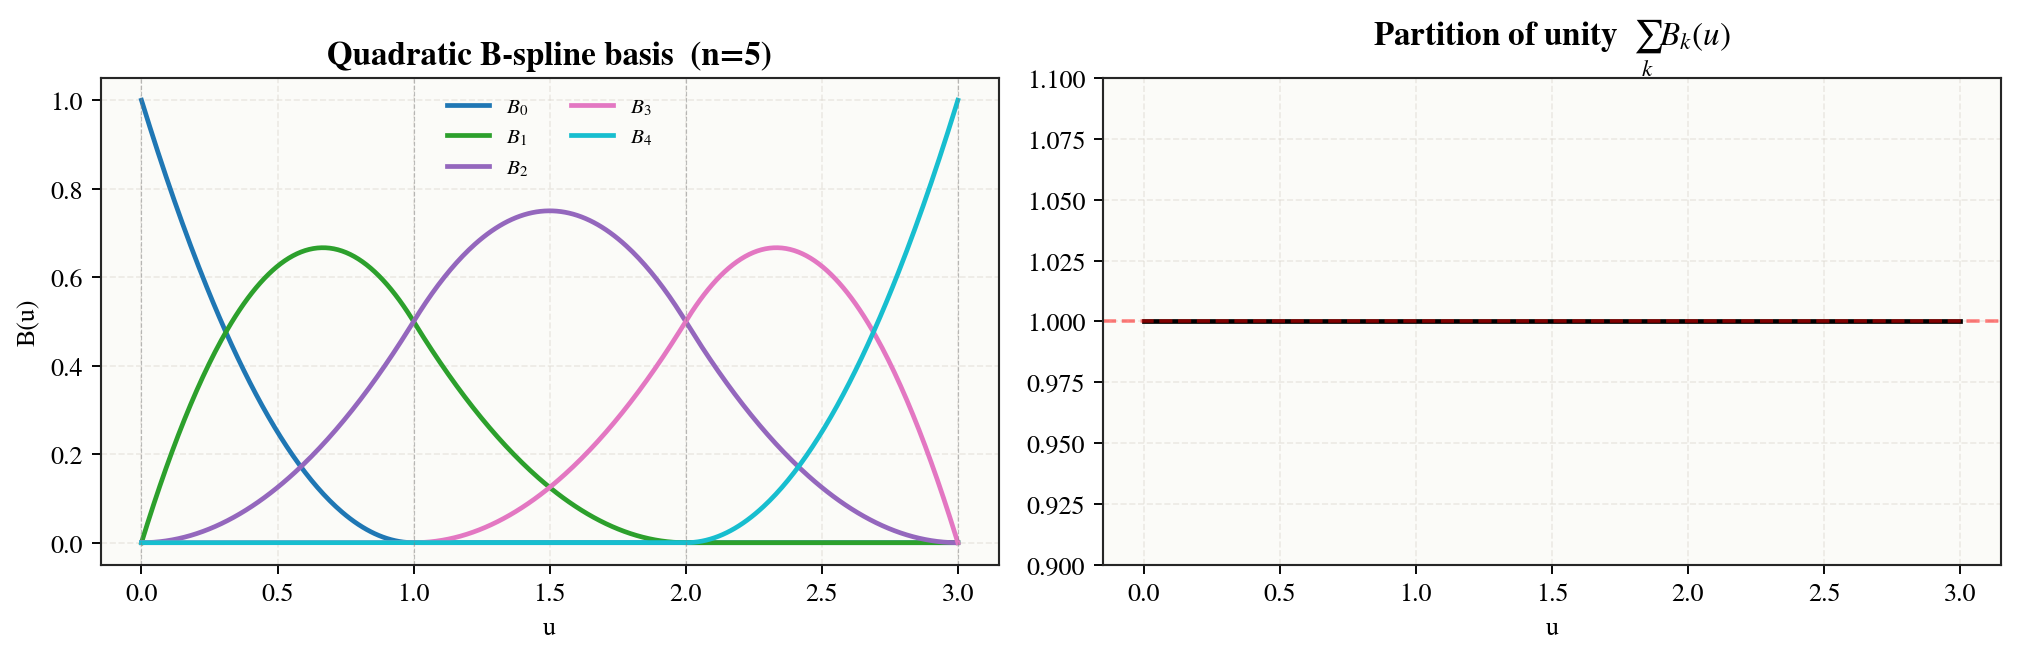

Max deviation from 1: 2.22e-16


In [2]:
# ── A complete quadratic B-spline basis on [0, 3] ──────────────────────────
T = np.array([0., 0., 0., 1., 2., 3., 3., 3.])   # clamped degree-2 knots
p = 2
n = len(T) - p - 1   # = 5 basis functions

u = np.linspace(0, 3, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: individual B-splines
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 0.9, n))
B_vals = np.zeros((len(u), n))
for i in range(n):
    end_pt = (i == n - 1)
    vals = np.array([_eval1d(ui, p, T[i:i+p+2], end_point=end_pt) for ui in u])
    B_vals[:, i] = vals
    ax.plot(u, vals, color=colors[i], lw=2, label=f'$B_{i}$')

for kv in np.unique(T):
    ax.axvline(kv, color='gray', lw=0.5, ls='--', alpha=0.5)
ax.set_title(f'Quadratic B-spline basis  (n={n})')
ax.set_xlabel('u');  ax.set_ylabel('B(u)')
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(-0.05, 1.05)

# Right: partition of unity check
ax = axes[1]
ax.plot(u, B_vals.sum(axis=1), 'k-', lw=2)
ax.set_ylim(0.9, 1.1)
ax.set_title('Partition of unity  $\\sum_k B_k(u)$')
ax.set_xlabel('u')
ax.axhline(1.0, color='red', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()
print(f'Max deviation from 1: {abs(B_vals.sum(axis=1) - 1).max():.2e}')

---
## 2. Tensor-product B-splines

In 2-D, a **tensor-product B-spline** is the product of two univariate B-splines:
$$
B_{ij}(u,v) = B_i(u) \cdot B_j(v)
$$

The full set $\{B_{ij}\}$ forms a basis for the tensor-product spline space and satisfies
partition of unity. This is the starting point for LR B-splines.

In [3]:
# ── Build a 5×5 biquadratic tensor-product basis ───────────────────────────
space = LRSplineSpace(
    knots_u=[0, 0, 0, 1, 2, 3, 3, 3],
    knots_v=[0, 0, 0, 1, 2, 3, 3, 3],
    degree_u=2, degree_v=2)

print(space)
print(f'  n_u = {len(space._global_knots_u) - space.degree_u - 1}  '
      f'n_v = {len(space._global_knots_v) - space.degree_v - 1}')

# Verify partition of unity
ok = space.check_partition_of_unity(n_pts=200)
print(f'  Partition of unity: {ok}')

LRSplineSpace(nfuncs=25, nelements=9, degree=(2,2))
  n_u = 5  n_v = 5
  Partition of unity: True


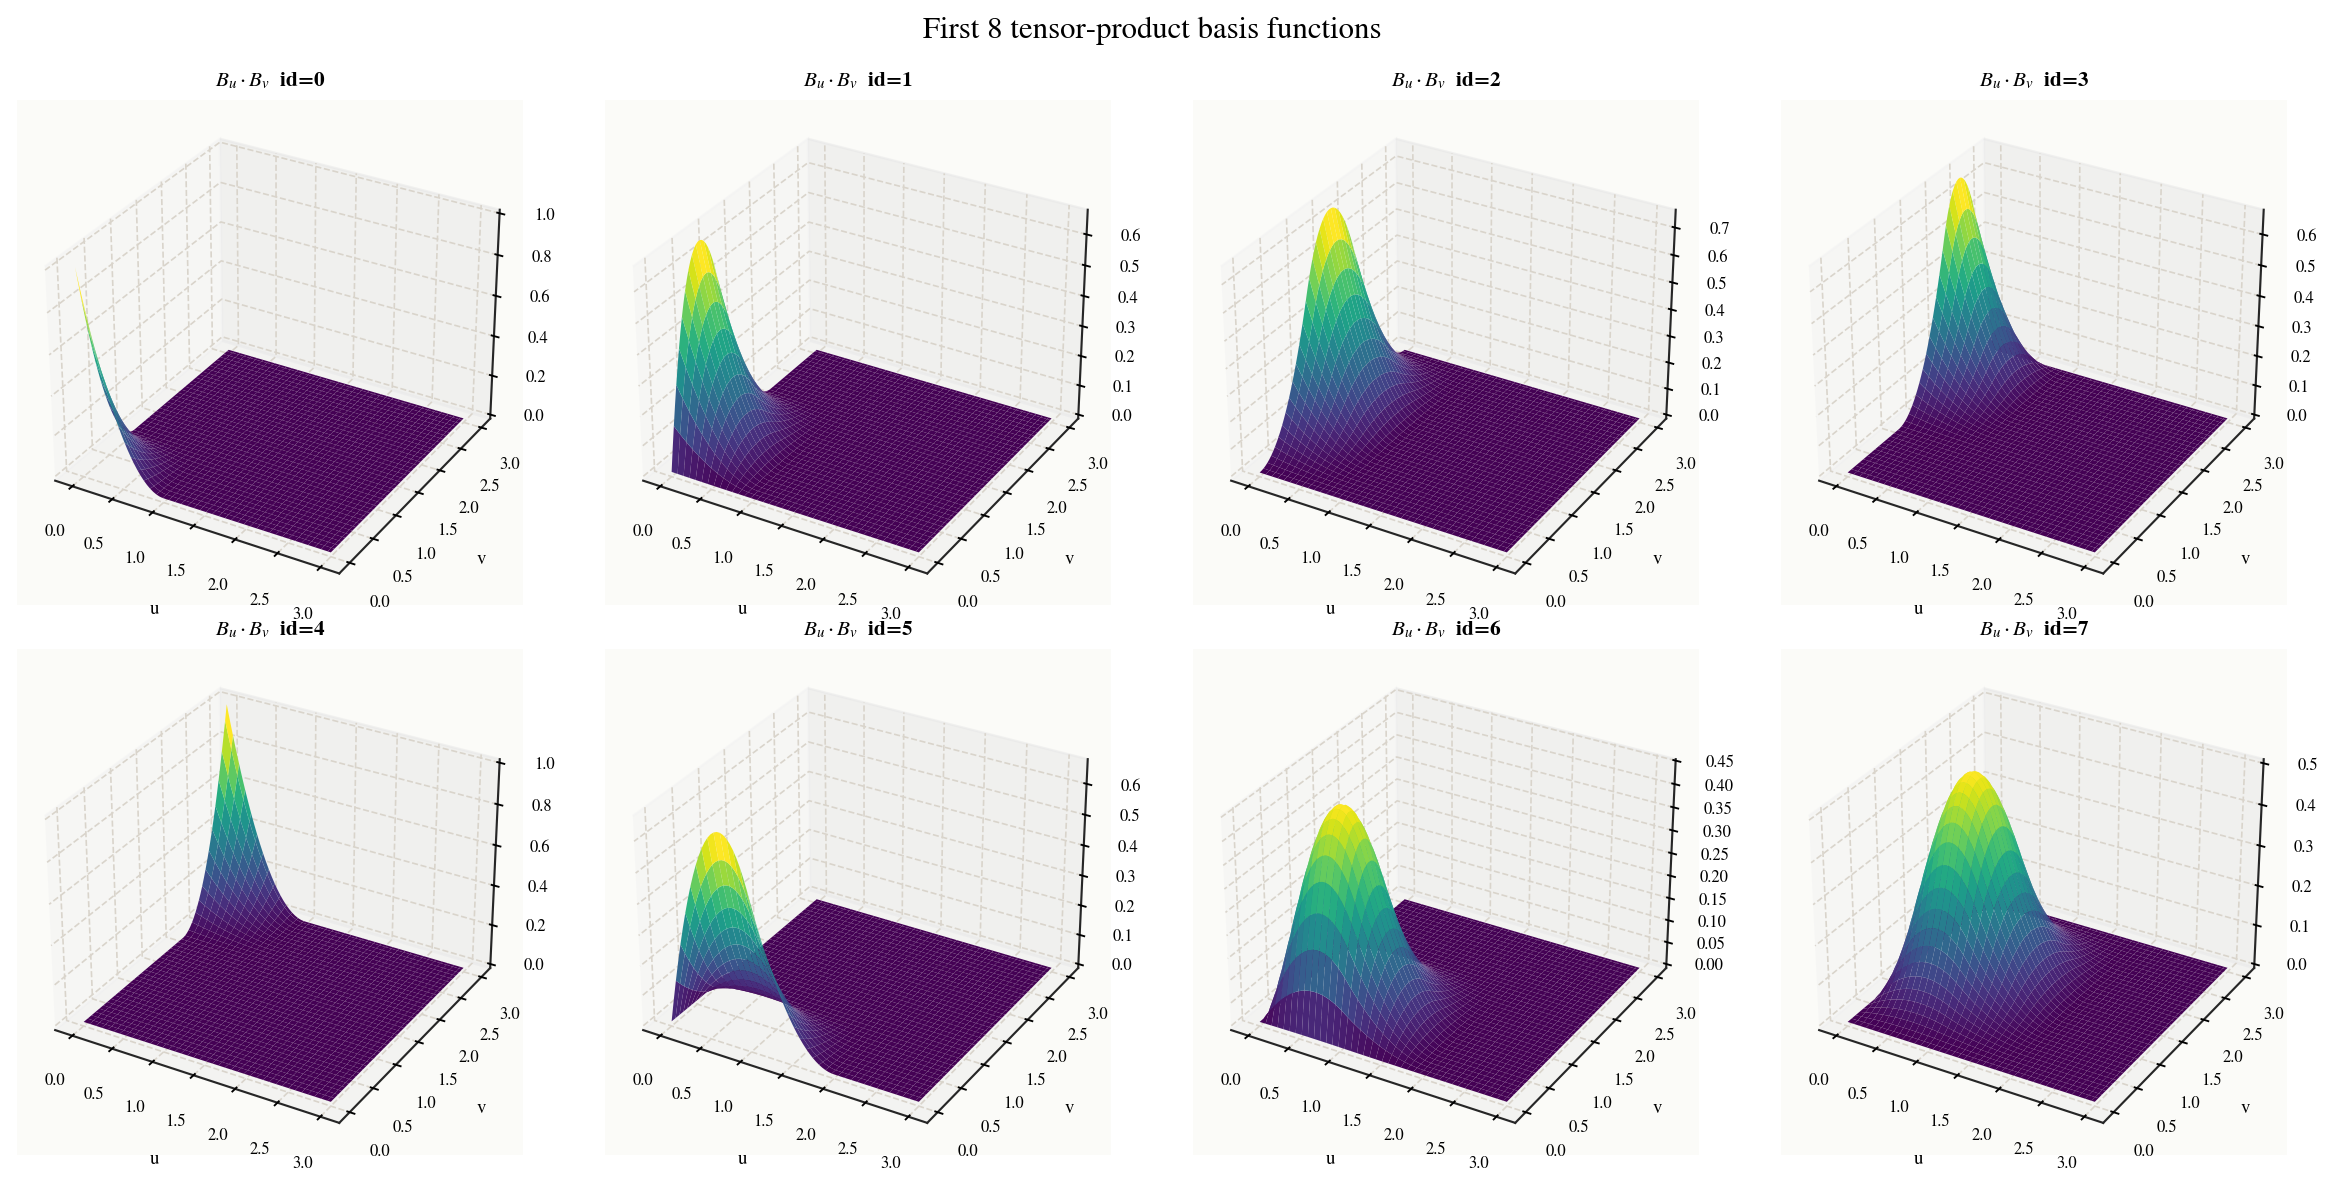

In [4]:
# ── Plot a few 2-D basis functions ──────────────────────────────────────────
ug = np.linspace(0.001, 2.999, 80)
vg = np.linspace(0.001, 2.999, 80)
UU, VV = np.meshgrid(ug, vg)
pts_grid = np.column_stack([UU.ravel(), VV.ravel()])

fig, axes = plt.subplots(2, 4, figsize=(14, 7), subplot_kw={'projection': '3d'})
for ax, B in zip(axes.ravel(), space.basis[:8]):
    Z = B.eval_array(pts_grid).reshape(UU.shape)
    ax.plot_surface(UU, VV, Z, cmap='viridis', linewidth=0, antialiased=True)
    ax.set_title(f'$B_{{u}}\\cdot B_{{v}}$  id={B.id}', fontsize=9)
    ax.set_xlabel('u', fontsize=8);  ax.set_ylabel('v', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('First 8 tensor-product basis functions', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. The LR mesh (T-mesh)

An **LR mesh** is a *T-mesh*: a partition of the parameter domain into rectangles by knot
line *segments* that need not span the full domain.  Where a segment terminates before
reaching the opposite boundary, a **T-junction** forms.

Key classes:

| Class | Description |
|-------|-------------|
| `MeshLine` | A single knot segment: `axis`, `value`, `start`, `end` |
| `Element`  | A rectangular element `[u0,u1]×[v0,v1]` with `active_functions` |
| `LRMesh`   | Collection of lines and elements; `insert_line()`, `plot()` |

Initial mesh: 9 elements
After T-junction at u=1.5 [0,2]: 11 elements


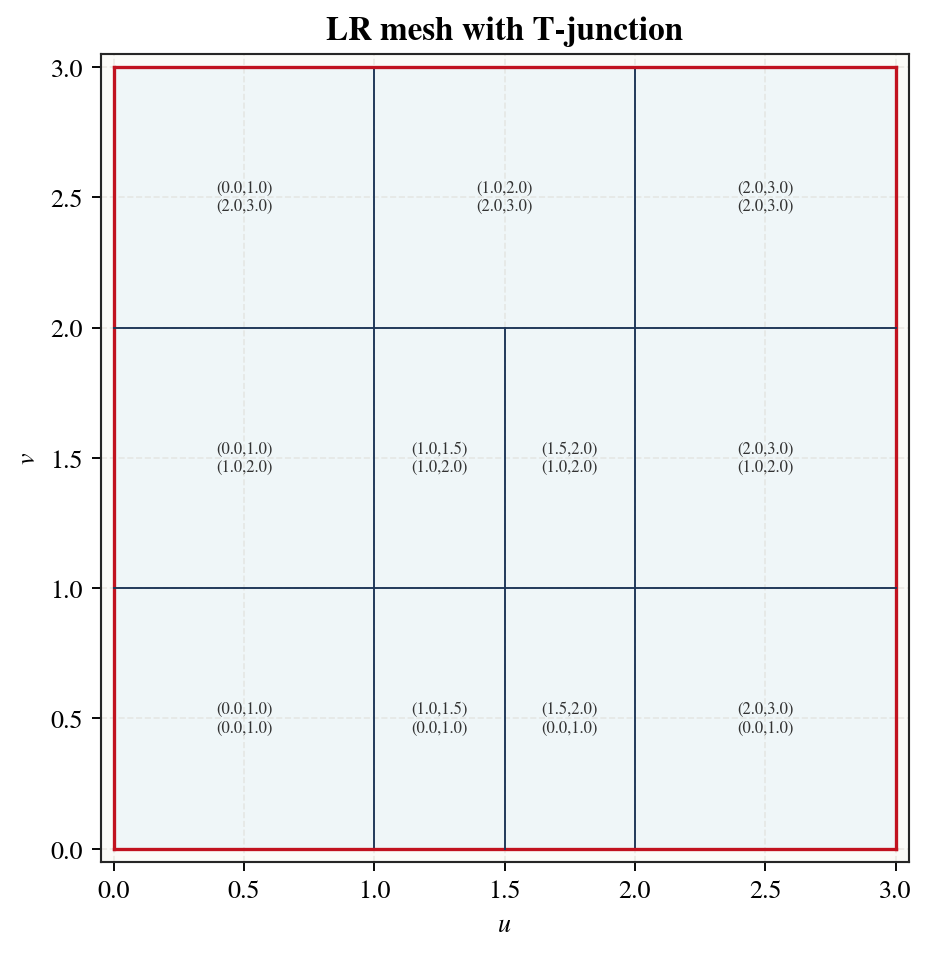

T-junction marker: line at u=1.5 terminates at v=2 (does not reach v=3)


In [5]:
# ── Build an LR mesh from scratch and insert a T-junction ──────────────────
mesh = LRMesh(
    u_knots=np.array([0., 0., 1., 2., 3., 3.]),
    v_knots=np.array([0., 0., 1., 2., 3., 3.]))

print(f'Initial mesh: {mesh.nelements} elements')

# Insert a partial vertical line (T-junction) at u=1.5 spanning v∈[0,2]
ln1 = MeshLine(axis=0, value=1.5, start=0.0, end=2.0)
mesh.insert_line(ln1)
print(f'After T-junction at u=1.5 [0,2]: {mesh.nelements} elements')

# Plot the mesh
fig, ax = mesh.plot(title='LR mesh with T-junction')

# Annotate elements
for el in mesh.elements:
    cx, cy = el.center
    ax.text(cx, cy, f'({el.u0:.1f},{el.u1:.1f})\n({el.v0:.1f},{el.v1:.1f})',
            ha='center', va='center', fontsize=7, color='#333')

plt.show()
print('T-junction marker: line at u=1.5 terminates at v=2 (does not reach v=3)')

---
## 4. Initial LR B-spline space

An `LRSplineSpace` starts as a full **tensor-product** space.  Each basis function carries:
- a local knot vector in $u$ and $v$  
- a scalar `coefficient` (initially 1)  
- `end_u` / `end_v` flags for the right-endpoint closed convention

The space stores the **global knot vectors** $T_u$ and $T_v$ so that global (Boehm) knot
insertion can be applied for full-line refinement.

In [6]:
# ── Create a biquadratic LR space on [0,3]² ─────────────────────────────────
space = LRSplineSpace(
    knots_u=[0, 0, 0, 1, 2, 3, 3, 3],
    knots_v=[0, 0, 0, 1, 2, 3, 3, 3],
    degree_u=2, degree_v=2)

print(space)

# Inspect a single basis function
B = space.basis[6]   # some interior function
print(f'\nBasis function  id={B.id}')
print(f'  knots_u = {B.knots_u}')
print(f'  knots_v = {B.knots_v}')
print(f'  support = {B.support}')
print(f'  Greville = {B.greville}')
print(f'  coefficient = {B.coefficient}')

LRSplineSpace(nfuncs=25, nelements=9, degree=(2,2))

Basis function  id=6
  knots_u = [0. 0. 1. 2.]
  knots_v = [0. 0. 1. 2.]
  support = (np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(2.0))
  Greville = (0.5, 0.5)
  coefficient = 1.0


In [7]:
# ── Evaluate all 25 basis functions and check PoU ───────────────────────────
rng = np.random.default_rng(42)
pts = rng.uniform([0.01, 0.01], [2.99, 2.99], (500, 2))
B_vals = space.evaluate(pts)          # shape (500, 25)

row_sums = B_vals.sum(axis=1)
print(f'Row sums — min: {row_sums.min():.6f}  max: {row_sums.max():.6f}')
print(f'Non-negativity: {(B_vals >= -1e-14).all()}')
print(f'Partition of unity: {np.allclose(row_sums, 1.0, atol=1e-10)}')

Row sums — min: 1.000000  max: 1.000000
Non-negativity: True
Partition of unity: True


---
## 5. Full-line refinement

A **full-line insertion** (spanning the entire domain) is a standard **Boehm knot
insertion** applied globally.  It always preserves partition of unity.

Internally, the new global knot vector is built from the old one, and the entire
tensor-product basis is reconstructed with coefficient = 1.

Before refinement: LRSplineSpace(nfuncs=25, nelements=9, degree=(2,2))
After u=1.5 full line: LRSplineSpace(nfuncs=30, nelements=12, degree=(2,2))
After v=1.5 full line: LRSplineSpace(nfuncs=36, nelements=16, degree=(2,2))

Partition of unity after 2 full lines: True
LLI satisfied: True


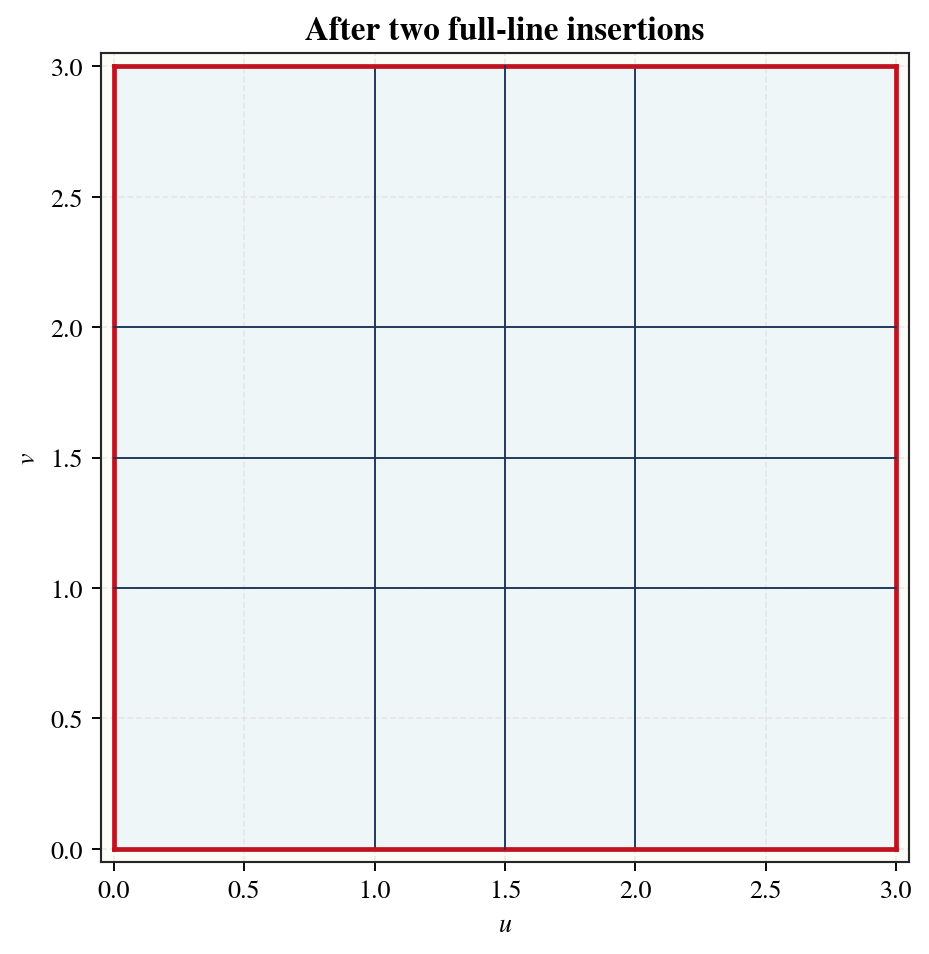

In [8]:
# ── Insert full lines in both directions ────────────────────────────────────
space = LRSplineSpace(
    knots_u=[0, 0, 0, 1, 2, 3, 3, 3],
    knots_v=[0, 0, 0, 1, 2, 3, 3, 3],
    degree_u=2, degree_v=2)

print(f'Before refinement: {space}')

# Insert vertical line at u=1.5 (axis=0)
refine(space, MeshLine(axis=0, value=1.5, start=0., end=3.))
print(f'After u=1.5 full line: {space}')

# Insert horizontal line at v=1.5 (axis=1)
refine(space, MeshLine(axis=1, value=1.5, start=0., end=3.))
print(f'After v=1.5 full line: {space}')

ok = space.check_partition_of_unity(n_pts=200)
print(f'\nPartition of unity after 2 full lines: {ok}')
print(f'LLI satisfied: {check_lli(space)}')

# Plot the mesh
fig, ax = space.mesh.plot(title='After two full-line insertions')
plt.show()

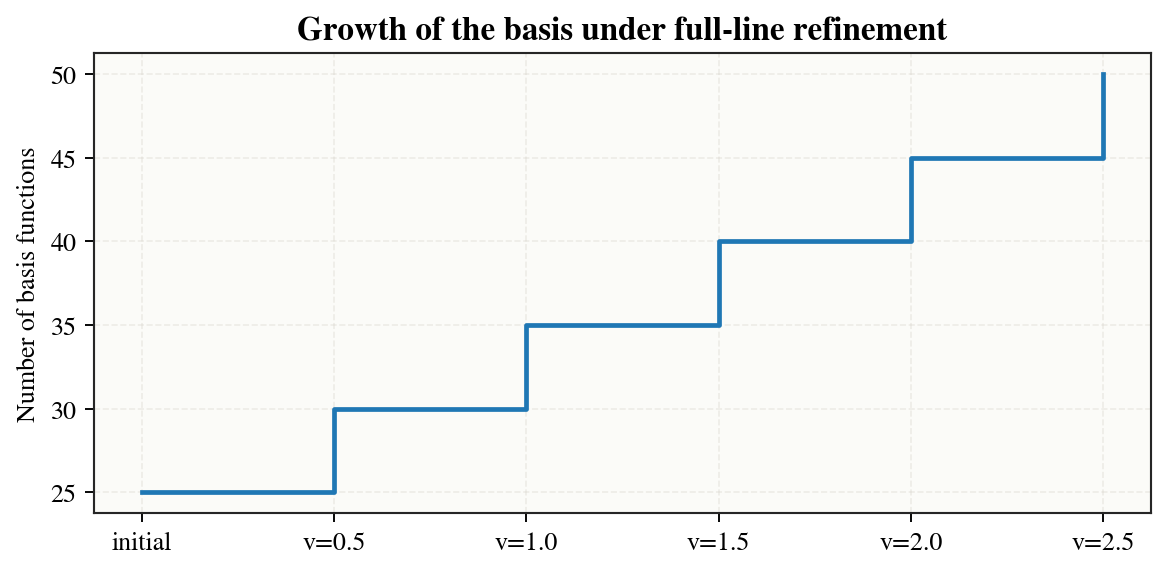

In [9]:
# ── Effect on the number of basis functions ─────────────────────────────────
counts = []
space2 = LRSplineSpace([0,0,0,1,2,3,3,3], [0,0,0,1,2,3,3,3], 2, 2)
counts.append(space2.nfuncs)

for v in [0.5, 1.0, 1.5, 2.0, 2.5]:
    refine(space2, MeshLine(axis=1, value=v, start=0., end=3.))
    counts.append(space2.nfuncs)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.step(range(len(counts)), counts, where='post', lw=2)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(['initial'] + [f'v={v}' for v in [0.5,1.0,1.5,2.0,2.5]])
ax.set_ylabel('Number of basis functions')
ax.set_title('Growth of the basis under full-line refinement')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## 6. Partial-line refinement (T-junctions)

A **partial-line insertion** (T-junction) is the distinguishing feature of LR B-splines.
Only basis functions that are *overloaded* by the new line are split:

> Function $B$ is **overloaded** by line $L$ if  
> (a) $L$'s fixed value is strictly inside $B$'s support in the normal direction, and  
> (b) $L$'s extent covers the entire projection of $B$'s support in the tangent direction.

Each overloaded function is replaced by two children via the **Boehm one-step knot
insertion**:
$$
N_i = c_\text{left}\,N'_\text{left} + c_\text{right}\,N'_\text{right}
\quad\text{where}\quad
c_\text{left} = \frac{t - \xi_0}{\xi_{p} - \xi_0},\quad
c_\text{right} = 1 - \frac{t - \xi_1}{\xi_{p+1} - \xi_1}
$$

Before: LRSplineSpace(nfuncs=25, nelements=9, degree=(2,2))
After partial line u=0.5 [0,2]: LRSplineSpace(nfuncs=31, nelements=11, degree=(2,2))
Partition of unity: True
LLI satisfied: False


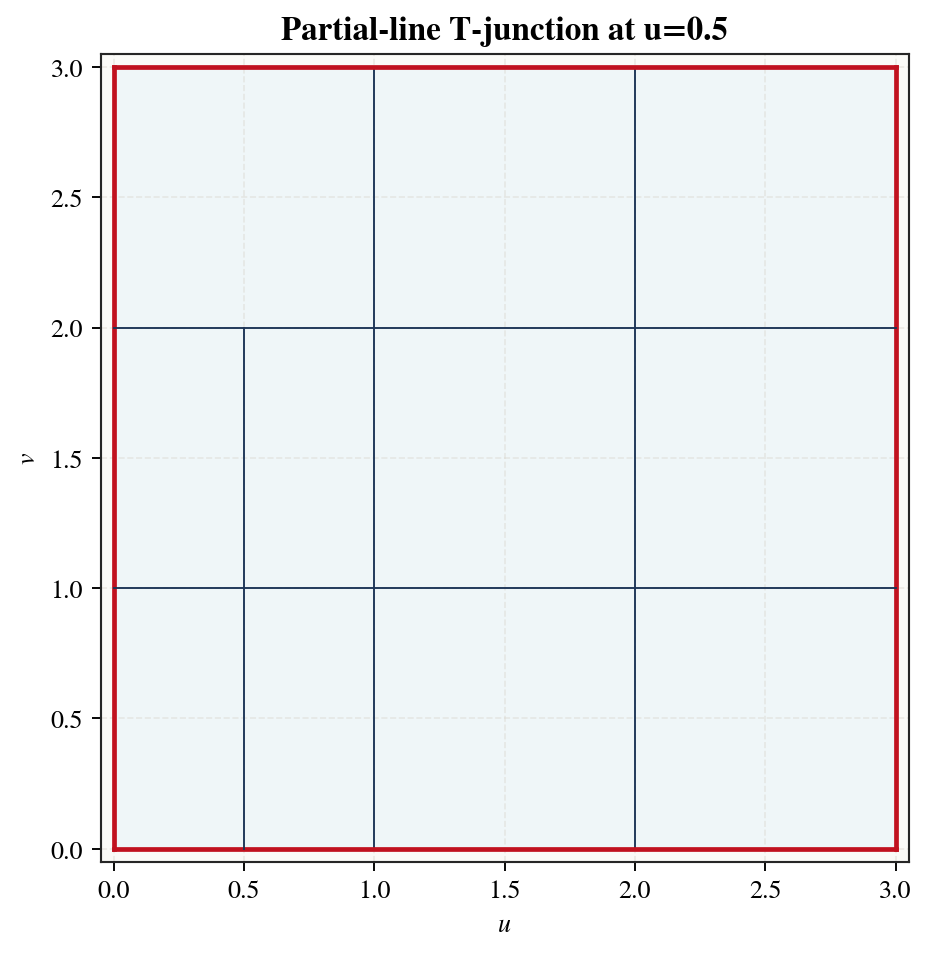

In [10]:
# ── Partial line insertion ───────────────────────────────────────────────────
space = LRSplineSpace(
    knots_u=[0, 0, 0, 1, 2, 3, 3, 3],
    knots_v=[0, 0, 0, 1, 2, 3, 3, 3],
    degree_u=2, degree_v=2)

print(f'Before: {space}')

# Partial vertical line at u=0.5 spanning v∈[0,2] (T-junction at v=2)
ln_partial = MeshLine(axis=0, value=0.5, start=0.0, end=2.0)
refine(space, ln_partial)

print(f'After partial line u=0.5 [0,2]: {space}')
print(f'Partition of unity: {space.check_partition_of_unity(n_pts=300)}')
print(f'LLI satisfied: {check_lli(space)}')

fig, ax = space.mesh.plot(title='Partial-line T-junction at u=0.5')
plt.show()

LRSplineSpace(nfuncs=33, nelements=10, degree=(2,2))
PoU: True
LLI: False


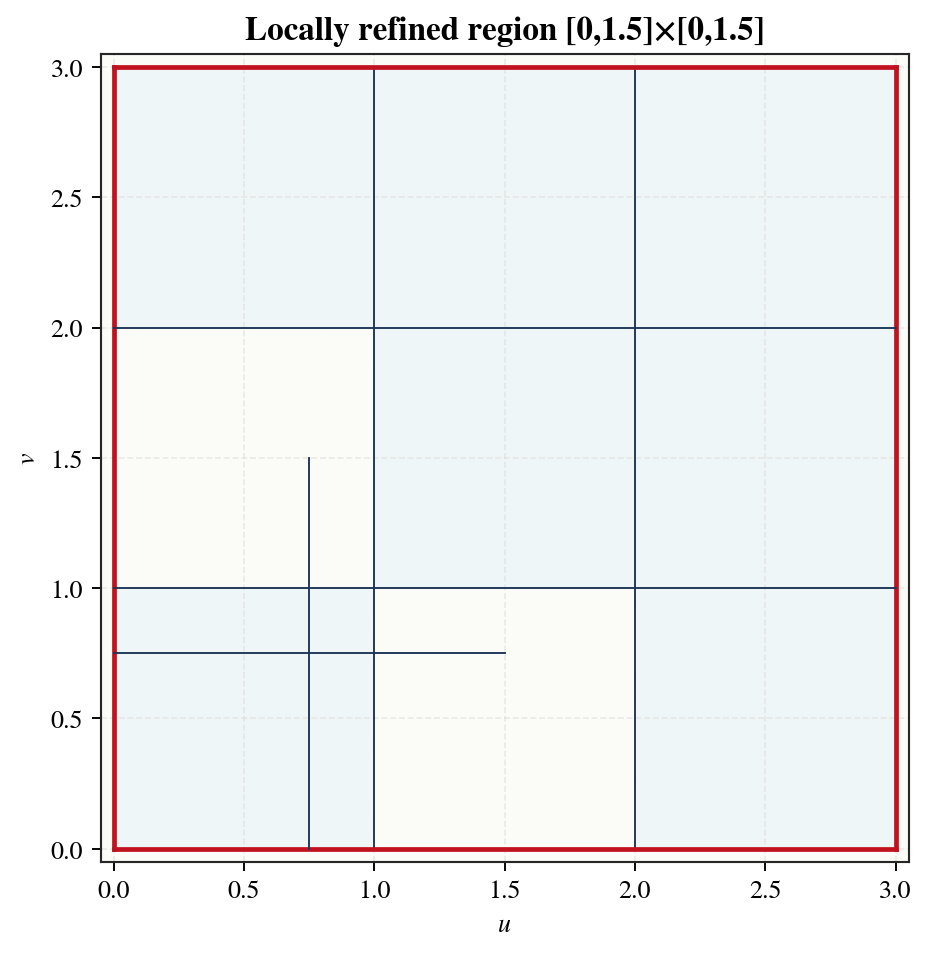

In [11]:
# ── Refine a rectangular region with partial lines ──────────────────────────
space2 = LRSplineSpace(
    knots_u=[0, 0, 0, 1, 2, 3, 3, 3],
    knots_v=[0, 0, 0, 1, 2, 3, 3, 3],
    degree_u=2, degree_v=2)

# Refine the bottom-left quadrant [0,1.5]×[0,1.5]
refine_region(space2, u0=0., u1=1.5, v0=0., v1=1.5, n_lines_u=1, n_lines_v=1)

print(space2)
print(f'PoU: {space2.check_partition_of_unity(n_pts=300)}')
print(f'LLI: {check_lli(space2)}')

fig, ax = space2.mesh.plot(title='Locally refined region [0,1.5]×[0,1.5]')
plt.show()

---
## 7. Partition of unity & local linear independence

Two key mathematical properties of a valid LR B-spline space:

**Partition of unity (PoU)**:  
$$\sum_k B_k(u,v) = 1 \quad \forall (u,v) \in \Omega$$

**Local linear independence (LLI)**:  
For each element $e$, the number of active basis functions satisfies:  
$$|\{B_k : \text{supp}(B_k) \cap \text{int}(e) \ne \emptyset\}| \le (p_u+1)(p_v+1)$$

In [12]:
# ── Build a space with multiple refinements and verify both properties ───────
space3 = LRSplineSpace(
    knots_u=[0, 0, 0, 1, 2, 3, 3, 3],
    knots_v=[0, 0, 0, 1, 2, 3, 3, 3],
    degree_u=2, degree_v=2)

# Insert several full lines
for v in [0.5, 1.5, 2.5]:
    refine(space3, MeshLine(axis=1, value=v, start=0., end=3.))
for u in [1.5]:
    refine(space3, MeshLine(axis=0, value=u, start=0., end=3.))

print(space3)
print(f'PoU holds: {space3.check_partition_of_unity(n_pts=500)}')
print(f'LLI holds: {check_lli(space3)}')

# Show active function counts per element
report = lli_report(space3)
max_allowed = (space3.degree_u + 1) * (space3.degree_v + 1)
print(f'\nMax allowed per element: {max_allowed}')
counts = [v['n_funcs'] for v in report.values()]
print(f'Active functions per element: min={min(counts)}, max={max(counts)}')

LRSplineSpace(nfuncs=48, nelements=24, degree=(2,2))
PoU holds: True
LLI holds: True

Max allowed per element: 9
Active functions per element: min=9, max=9


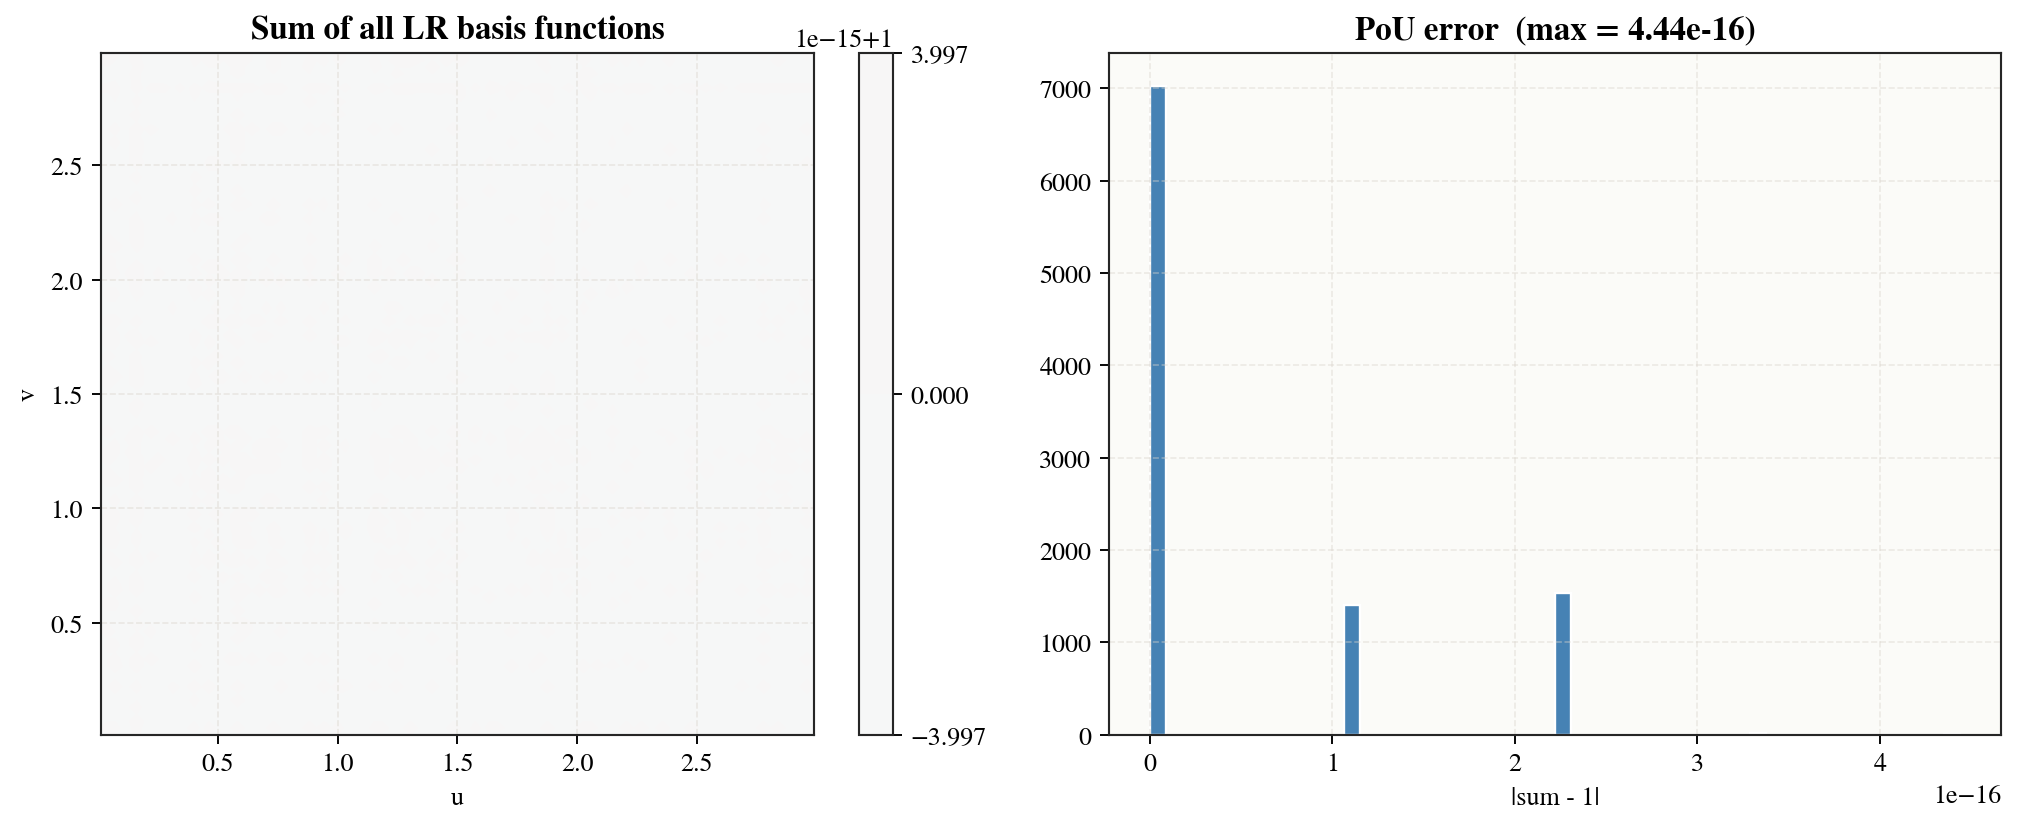

In [13]:
# ── Visualise the sum of all basis functions ─────────────────────────────────
ug = np.linspace(0.01, 2.99, 100)
vg = np.linspace(0.01, 2.99, 100)
UU, VV = np.meshgrid(ug, vg)
pts_g = np.column_stack([UU.ravel(), VV.ravel()])

Bmat = space3.evaluate(pts_g)
sums = Bmat.sum(axis=1).reshape(UU.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
cf = ax.contourf(UU, VV, sums, levels=50, cmap='RdBu_r', vmin=0.999, vmax=1.001)
plt.colorbar(cf, ax=ax)
ax.set_title('Sum of all LR basis functions')
ax.set_xlabel('u');  ax.set_ylabel('v')

ax = axes[1]
err = np.abs(sums - 1.0)
ax.hist(err.ravel(), bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('|sum - 1|')
ax.set_title(f'PoU error  (max = {err.max():.2e})')

plt.tight_layout()
plt.show()

---
## 8. Assembling mass and stiffness matrices

For finite element analysis, we need:

$$
M_{ij} = \int_\Omega B_i\,B_j\,\mathrm{d}\Omega, \qquad
A_{ij} = \int_\Omega \nabla B_i \cdot \nabla B_j\,\mathrm{d}\Omega
$$

Both are assembled element-by-element using **Gauss–Legendre quadrature** on each
rectangular element.

In [14]:
# ── Build a simple space for assembly ───────────────────────────────────────
sp_asm = LRSplineSpace(
    knots_u=[0, 0, 0, 0.5, 1, 1, 1],
    knots_v=[0, 0, 0, 0.5, 1, 1, 1],
    degree_u=2, degree_v=2)

print(sp_asm)

# Assemble matrices
M = lr_mass_matrix(sp_asm, gauss_order=4)
A = lr_stiffness_matrix(sp_asm, gauss_order=4)

print(f"\nMass matrix M: shape={M.shape}, nnz={M.nnz}")
print(f"  Symmetric: {np.allclose(M.toarray(), M.toarray().T)}")
# Row sums = ∫ B_i dΩ (integral of each basis function)
# Their total = area of Ω, by partition of unity: Σ_i ∫ B_i = ∫ 1 = area
row_sums = np.asarray(M.sum(axis=1)).ravel()
print(f"  Row sums (∫ B_i dΩ): min={row_sums.min():.4f}  max={row_sums.max():.4f}")
print(f"  Σ row sums = area of Ω = {row_sums.sum():.4f}")
print(f"\nStiffness matrix A: shape={A.shape}, nnz={A.nnz}")
print(f"  Symmetric: {np.allclose(A.toarray(), A.toarray().T)}")

LRSplineSpace(nfuncs=16, nelements=4, degree=(2,2))



Mass matrix M: shape=(16, 16), nnz=196
  Symmetric: True
  Row sums (∫ B_i dΩ): min=0.0278  max=0.1111
  Σ row sums = area of Ω = 1.0000

Stiffness matrix A: shape=(16, 16), nnz=192
  Symmetric: True


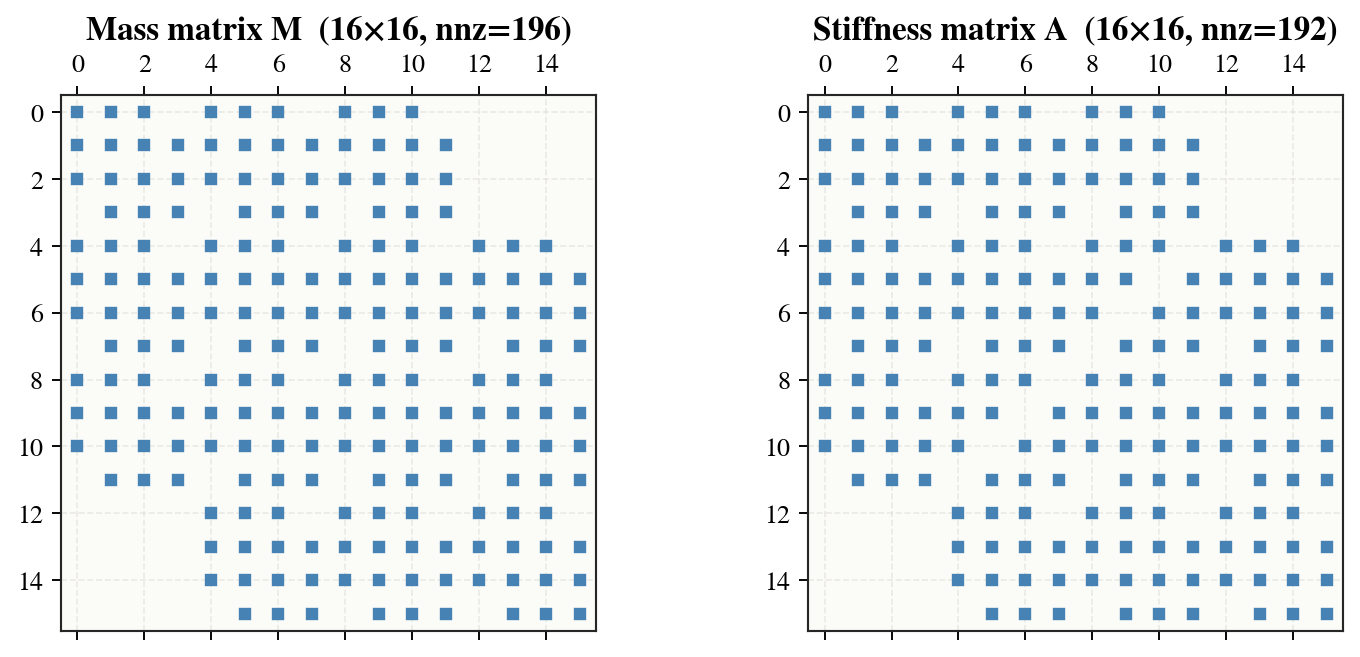

In [15]:
# ── Sparsity patterns ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, mat, title in zip(axes, [M, A], ['Mass matrix M', 'Stiffness matrix A']):
    ax.spy(mat, markersize=4, color='steelblue')
    ax.set_title(f'{title}  ({mat.shape[0]}×{mat.shape[1]}, nnz={mat.nnz})')
plt.tight_layout()
plt.show()

---
## 9. Solving the Poisson equation with LR B-splines

We solve the **Poisson problem** on the unit square $\Omega = [0,1]^2$:

$$
-\Delta u = f \quad \text{in } \Omega, \qquad u = 0 \quad \text{on } \partial\Omega
$$

with manufactured solution $u^*(x,y) = \sin(\pi x)\sin(\pi y)$, so $f = 2\pi^2\sin(\pi x)\sin(\pi y)$.

We use an LR B-spline space adaptively refined in the region where $u$ is large.

In [ ]:
# ── Build a biquadratic space on [0,1]² with local refinement ───────────────
# Same knot vector and refinement rectangle as the THBSplines Poisson problem,
# so results are directly comparable.
sp_poisson = LRSplineSpace(
    knots_u=[0, 0, 0, 0.25, 0.5, 0.75, 1, 1, 1],
    knots_v=[0, 0, 0, 0.25, 0.5, 0.75, 1, 1, 1],
    degree_u=2, degree_v=2)

# Locally refine the central region [0.25, 0.75]²
refine_region(sp_poisson, 0.25, 0.75, 0.25, 0.75, n_lines_u=2, n_lines_v=2)

print(f'Total DOFs: {sp_poisson.nfuncs}')
print(f'PoU holds: {sp_poisson.check_partition_of_unity()}')

fig, ax = plt.subplots(figsize=(4.8, 4.8), constrained_layout=True)
sp_poisson.mesh.plot(ax=ax)
style_axes(ax, square=True, xlabel='$x$', ylabel='$y$',
           title='Adaptive LR Mesh for the Poisson Problem')
ax.set_facecolor('white')

In [17]:
# ── Assemble stiffness matrix and load vector ────────────────────────────────

# Right-hand side  f(x,y) = 2π² sin(πx) sin(πy)
def f_rhs(pts):
    return 2 * np.pi**2 * np.sin(np.pi * pts[:, 0]) * np.sin(np.pi * pts[:, 1])


A_full = lr_stiffness_matrix(sp_poisson, gauss_order=5)
F      = lr_load_vector(sp_poisson, f_rhs, gauss_order=5)

print(f'Stiffness matrix shape : {A_full.shape}')
print(f'Load vector shape      : {F.shape}')

Stiffness matrix shape : (36, 36)
Load vector shape      : (36,)


In [18]:
# ── Apply zero Dirichlet boundary conditions ──────────────────────────────────
#
# LR B-splines expose Greville abscissae directly via sp_poisson.greville_points.
# A DOF is on the boundary iff its Greville point lies on ∂[0,1]².

eps = 1e-12
greville = sp_poisson.greville_points   # (nfuncs, 2)
on_boundary = (
    (greville[:, 0] < eps) | (greville[:, 0] > 1 - eps) |
    (greville[:, 1] < eps) | (greville[:, 1] > 1 - eps)
)
interior = np.where(~on_boundary)[0]
print(f'Interior DOFs: {len(interior)} / {sp_poisson.nfuncs}')

# Extract the interior sub-system
Ap_csr = A_full.tocsr()
A_int  = Ap_csr[np.ix_(interior, interior)]
f_int  = F[interior]

# Solve with sparse direct solver
c_int = spla.spsolve(A_int, f_int)

# Assemble full coefficient vector (boundary DOFs = 0)
c_full = np.zeros(sp_poisson.nfuncs)
c_full[interior] = c_int
print('Solve complete.')

Interior DOFs: 16 / 36
Solve complete.


L² error (discrete): 2.2843e-03


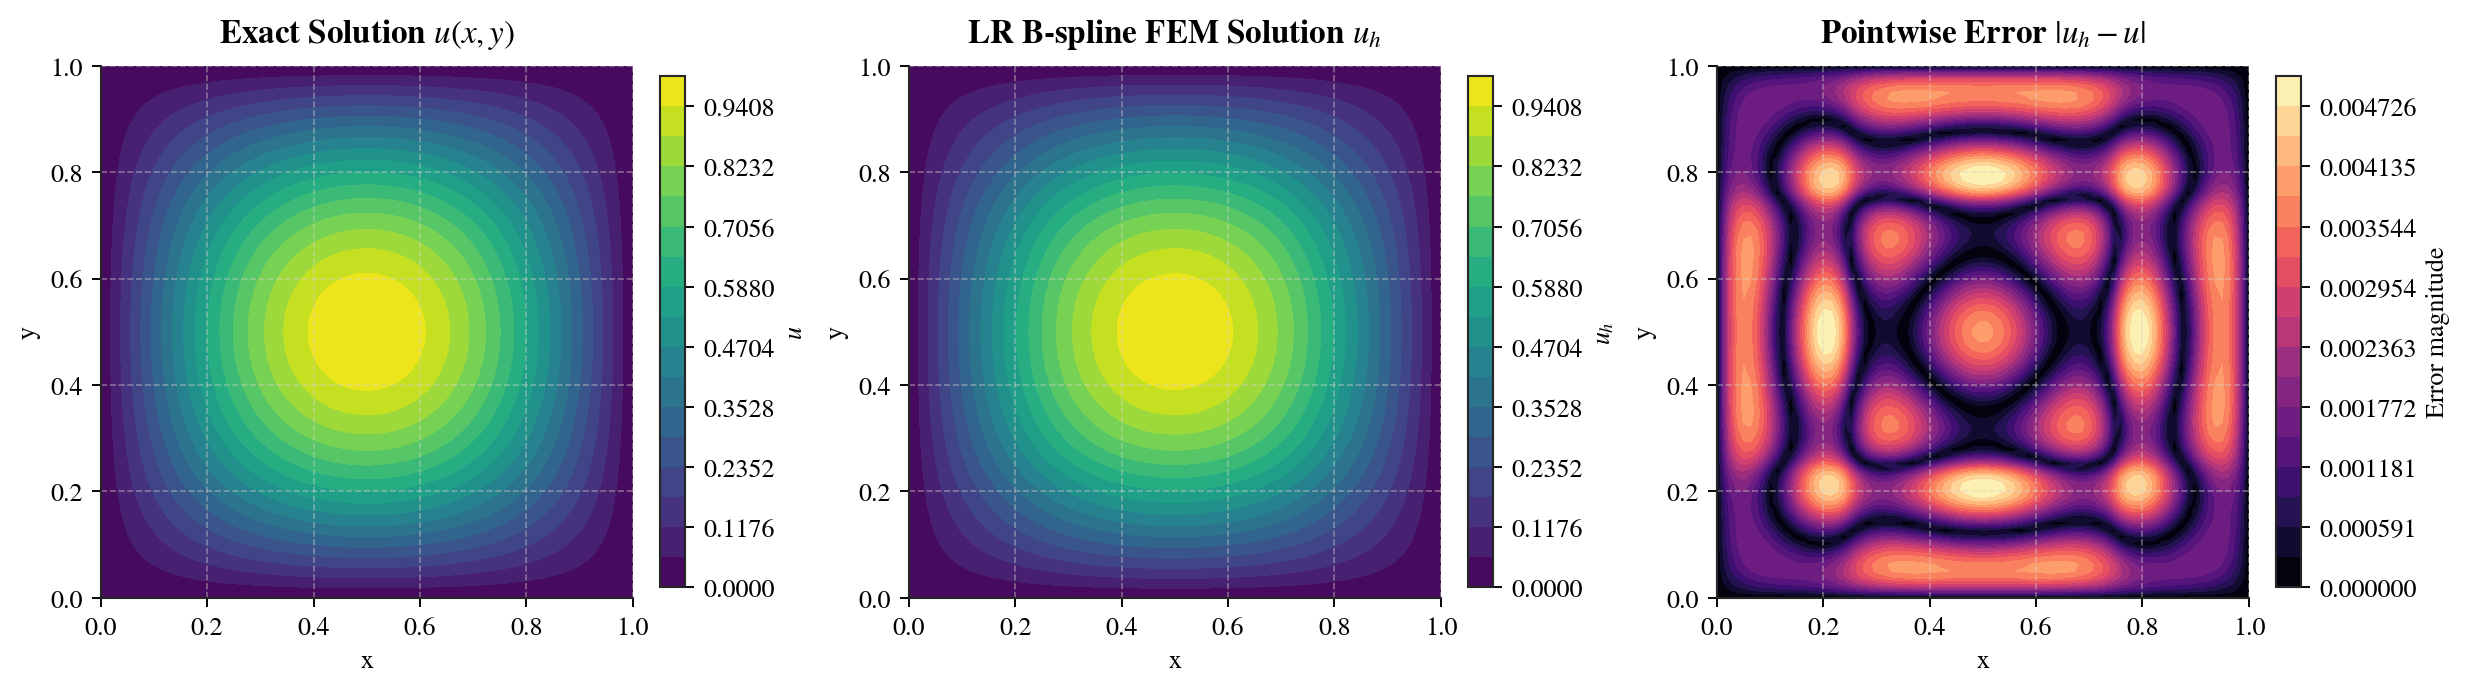

In [19]:
# ── Evaluate and plot the solution ────────────────────────────────────────────
n_plot = 80
x1d_p = np.linspace(0, 1, n_plot)
X_p, Y_p = np.meshgrid(x1d_p, x1d_p)
pts_p = np.column_stack([X_p.ravel(), Y_p.ravel()])

Bmat   = sp_poisson.evaluate(pts_p)            # (n_pts, nfuncs)
u_h    = (Bmat * c_full).sum(axis=1).reshape(n_plot, n_plot)
u_exact = np.sin(np.pi * X_p) * np.sin(np.pi * Y_p)
pointwise_err = np.abs(u_h - u_exact)

fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.5), constrained_layout=True)

solution_levels = np.linspace(0.0, max(u_exact.max(), u_h.max()), 18)
err_levels      = np.linspace(0.0, pointwise_err.max(), 18)

contour_panel(fig, axes[0], X_p, Y_p, u_exact, levels=solution_levels, cmap=SURFACE_CMAP,
              title=r'Exact Solution $u(x,y)$', colorbar_label='$u$')
contour_panel(fig, axes[1], X_p, Y_p, u_h,     levels=solution_levels, cmap=SURFACE_CMAP,
              title=r'LR B-spline FEM Solution $u_h$', colorbar_label='$u_h$')
contour_panel(fig, axes[2], X_p, Y_p, pointwise_err, levels=err_levels, cmap=ERROR_CMAP,
              title=r'Pointwise Error $|u_h-u|$', colorbar_label='Error magnitude')

L2_err = np.sqrt(np.mean((u_h - u_exact)**2))
print(f'L² error (discrete): {L2_err:.4e}')

---
## Summary

| Section | Topic | Key class / function |
|---------|-------|----------------------|
| 1 | Univariate B-splines | `_eval1d`, `_deriv1d` |
| 2 | Tensor-product space | `LRSplineSpace`, `LRBasisFunction` |
| 3 | LR mesh (T-mesh) | `LRMesh`, `MeshLine`, `Element` |
| 4 | Initial LR space | `LRSplineSpace(knots_u, knots_v, p, q)` |
| 5 | Full-line refinement | `refine(space, MeshLine(...))` |
| 6 | Partial-line (T-junctions) | `refine`, `refine_region` |
| 7 | PoU & LLI | `check_partition_of_unity`, `check_lli` |
| 8 | Assembly | `lr_mass_matrix`, `lr_stiffness_matrix`, `lr_load_vector` |
| 9 | Poisson solve | Full FEM pipeline with Dirichlet BC |

**Key advantages of LR B-splines over THB-splines:**
- Local refinement does not require a hierarchical structure
- T-junctions arise naturally without ghost points
- The Boehm splitting coefficients guarantee exact reproduction of parent functions

**Limitations:**
- Linear independence is not automatic — requires the LLI check after each insertion
- Partial-line insertions may require additional "stabilizing" lines in some cases